#Day 21: Early Stopping in TensorFlow

##1. Introduction to Early Stopping
Early Stopping is a form of regularization that halts the training process when the validation performance stops improving. It’s essential for preventing overfitting and saving computation time.

##2. Building a Neural Network with Early Stopping


In [ ]:
import tensorflow as tf
import numpy as np

# Generating a simple dataset
X_train = np.random.rand(200, 5)  # 200 samples, 5 features
y_train = np.random.rand(200, 1)  # 200 target values

# Creating an EarlyStopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',  # Monitors validation loss
    patience=3,  # Stops training after 3 epochs of no improvement
    restore_best_weights=True  # Restores weights from the epoch with the best validation loss
)

# Building a simple neural network model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(5,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

# Compiling the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Training the model with Early Stopping
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stopping])


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - loss: 0.4650 - val_loss: 0.3024
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.3396 - val_loss: 0.2150
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2492 - val_loss: 0.1499
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1587 - val_loss: 0.1049
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1142 - val_loss: 0.0809
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1011 - val_loss: 0.0778
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0810 - val_loss: 0.0844
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0968 - val_loss: 0.0866
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1021 - val_loss: 0.0816


3. Evaluating the Model Performance


In [ ]:
# Generating test data
X_test = np.random.rand(50, 5)
y_test = np.random.rand(50, 1)

# Evaluating the model on test data
test_loss = model.evaluate(X_test, y_test)
print(f"Test Loss with Early Stopping: {test_loss}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0823 
Test Loss with Early Stopping: 0.08304407447576523


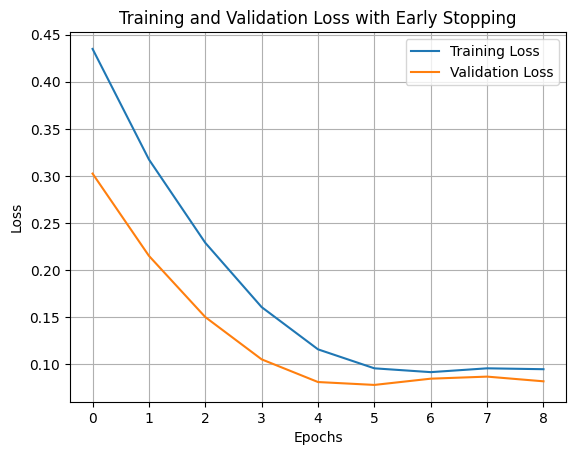

In [ ]:
import matplotlib.pyplot as plt

# Plotting the loss curves
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss with Early Stopping')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


### Key Benefits of Early Stopping:
1. Prevents overfitting by halting training when the model starts to overtrain on the data.
2. Reduces training time by avoiding unnecessary epochs.
3. Restores the model to the best weights found during training.


##Conclusion
Early Stopping is a simple yet powerful technique that enhances your model’s performance while making the training process more efficient. By stopping training at the right time, you avoid overfitting and save valuable time and resources.